In [1]:
import warnings

import pandas as pd
from h5py.h5z import FLAG_SKIP_EDC
import numpy as np
import math
import matplotlib.pyplot as plt

from pandas.io.sas.sas_constants import sas_date_formats

from utils import *

legend = ['1.57 nM EGF', '100 nM INS', '1.57 nM EGF + 100 nM INS'] 
color_palette = ['r', 'b', 'fuchsia']

In [2]:
# df_2_HME1 = pd.read_excel('Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1.xlsx')
# df_1_HME1 = pd.read_excel('Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1.xlsx')
# df_1_HEK = pd.read_excel("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T.xlsx")
df_2_hME1_scaled = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff_renamed_scaled.xlsx")


In [3]:
len(df_2_hME1_scaled["site"].unique())

50014

In [4]:
df_2_HME1 = df_2_hME1_scaled.fillna(0)
# df_1_HME1 = df_1_HME1.fillna(0)
# df_1_HEK = df_1_HEK.fillna(0)

In [5]:
def plot_protein_phosphosites(df, data_type = str, experiment = str,  
                              proteins=list, replicates = False,  exclude_rep = list, 
                              legend_plot = list, color_palette = ['r', 'b', 'fuchsia'],
                              saving_path=str, saving_info="", title_info = "",
                              plot_individually=False, fit_y_lims=False, 
                              plot_close=False,  
                              save_pdf=False, save_png=False):
    '''Plot to PDF ALL phosphosites of a list of proteins. You can decide to plot the phosphosties of the protein
    together in one plot or to plot them separatly.'''

    # Check if the df is a pandas dataframe already or the path to it
    if type(df) == pd.DataFrame:
        pass
    else:
        df = pd.read_excel(df)

    # If the file generated is not going to be saved don't create the saving folder
    if save_pdf == False and save_png == False:
        pass
    else:  # If the files are going to be saved, check if the path exist, if not, create it
        if not os.path.exists(saving_path):
            print("Creating saving folder")
            os.makedirs(saving_path)
    

    for protein in proteins:
        # Create sub-dataframe with only the protein we are interested in. If the protein doesn't exist in the dataframe skip code
        if protein in df['protein_name'].to_list():
            sub_df = df.loc[df['protein_name'] == protein].copy()
            print(f"Ploting sites of protein {protein}")
        elif protein in df['protein_Id'].to_list():
            sub_df = df.loc[df['protein_Id'] == protein].copy()
            print(f"Ploting sites of protein {protein}")
        else:
            print(f"The protein {protein} is not present in the dataset")
            continue

        # Extract the protein name and protein uniprot code for the folder
        saving_folder = f"{list(sub_df.protein_name)[0]}_{list(sub_df.protein_Id)[0]}"

        # Check if a folder for the desired protein exists. If no, create one
        if save_pdf == False and save_png == False:
            pass
        else:
            if saving_folder in os.listdir(saving_path):
                pass
            else:
                new_path = f"{saving_path}/{saving_folder}"
                print(f"Createating saving folder for {saving_folder}")
                os.makedirs(new_path)

        # Sort the pepetides of the dataframe for better interpretation of the figure generated
        sub_df.sort_values(by=['site'], inplace=True)
        
        # Determine the dimentional space for the subplot
        number_phos = len(sub_df)        
        sqrt_n_p = int(np.ceil(np.sqrt(number_phos)))  # Plotting time points in a matrix
        if sqrt_n_p <= 2:  # 1 plot doesn't work, 2 plots leave empty row below
            empty_plots = 0
        else:
            empty_plots = (sqrt_n_p * sqrt_n_p) - number_phos
        # Avoid getting rows with empty plots
        if empty_plots >= sqrt_n_p:
            sqrt_n_p_X = sqrt_n_p - 1
        else:
            sqrt_n_p_X = sqrt_n_p
            
        # Columns to determine the "y" axis limit values
        if experiment == "2_hTERT_HME1" or experiment == "1_HEK293T":
            all_raw_columns = ["mean_raw_EGF_full", "mean_raw_EGF_starve", "mean_raw_EGF2", "mean_raw_EGF5", "mean_raw_EGF10", "mean_raw_EGF15", "mean_raw_EGF90", "mean_raw_INS_full", "mean_raw_INS_starve", "mean_raw_INS2", "mean_raw_INS5", "mean_raw_INS10", "mean_raw_INS15", "mean_raw_INS90", "mean_raw_EGFnINS_full", "mean_raw_EGFnINS_starve", "mean_raw_EGFnINS2", "mean_raw_EGFnINS5", "mean_raw_EGFnINS10", "mean_raw_EGFnINS15", "mean_raw_EGFnINS90"]
            all_log2_columns = ["mean_EGF_full", "mean_EGF_starve", "mean_EGF2", "mean_EGF5", "mean_EGF10", "mean_EGF15", "mean_EGF90", "mean_INS_full", "mean_INS_starve", "mean_INS2", "mean_INS5", "mean_INS10", "mean_INS15", "mean_INS90", "mean_EGFnINS_full", "mean_EGFnINS_starve", "mean_EGFnINS2", "mean_EGFnINS5", "mean_EGFnINS10", "mean_EGFnINS15", "mean_EGFnINS90"]
            all_log2FC_columns = ["FC_EGF_full", "FC_EGF_starve", "FC_EGF2", "FC_EGF5", "FC_EGF10", "FC_EGF15", "FC_EGF90", "FC_INS_full", "FC_INS_starve", "FC_INS2", "FC_INS5", "FC_INS10", "FC_INS15", "FC_INS90", "FC_EGFnINS_full", "FC_EGFnINS_starve", "FC_EGFnINS2", "FC_EGFnINS5", "FC_EGFnINS10", "FC_EGFnINS15", "FC_EGFnINS90"]
        else:
            all_raw_columns = ["mean_raw_EGF_full", "mean_raw_EGF_starve", "mean_raw_EGF1","mean_raw_EGF2", "mean_raw_EGF5", "mean_raw_EGF10",  "mean_raw_EGF90", "mean_raw_INS_full", "mean_raw_INS_starve", "mean_raw_INS1", "mean_raw_INS2", "mean_raw_INS5", "mean_raw_INS10", "mean_raw_INS90", "mean_raw_EGFnINS_full", "mean_raw_EGFnINS_starve", "mean_raw_EGFnINS1", "mean_raw_EGFnINS2", "mean_raw_EGFnINS5", "mean_raw_EGFnINS10",  "mean_raw_EGFnINS90"]
            all_log2_columns = ["mean_EGF_full", "mean_EGF_starve", "mean_EGF1","mean_EGF2", "mean_EGF5", "mean_EGF10",  "mean_EGF90", "mean_INS_full", "mean_INS_starve", "mean_INS1", "mean_INS2", "mean_INS5", "mean_INS10", "mean_INS90", "mean_EGFnINS_full", "mean_EGFnINS_starve", "mean_EGFnINS1", "mean_EGFnINS2", "mean_EGFnINS5", "mean_EGFnINS10",  "mean_EGFnINS90"]
            all_log2FC_columns = ["FC_EGF_full", "FC_EGF_starve", "FC_EGF1","FC_EGF2", "FC_EGF5", "FC_EGF10",  "FC_EGF90", "FC_INS_full", "FC_INS_starve", "FC_INS1", "FC_INS2", "FC_INS5", "FC_INS10", "FC_INS90", "FC_EGFnINS_full", "FC_EGFnINS_starve", "FC_EGFnINS1", "FC_EGFnINS2", "FC_EGFnINS5", "FC_EGFnINS10",  "FC_EGFnINS90"]
           
        if plot_individually == True:
            for index, row in sub_df.iterrows():
                
                protein_name = row["protein_name"]
                site = row["site"]
                # Y axis limit
                if fit_y_lims == True:
                    y_fixed = "y_axis_fixed"
                elif type(fit_y_lims) == list:
                    y_lim_min = fit_y_lims[0]
                    y_lim_max = fit_y_lims[1]
                    y_fixed = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
                elif fit_y_lims == False:
                    if data_type == "raw":
                        sub_values_df = sub_df.loc[:,all_raw_columns]
                        y_lim_max = (sub_values_df.max().max()) * 1.05
                        y_lim_min = (sub_values_df.min().min()) * 0.95
                    elif data_type == "log2":
                        sub_values_df = sub_df.loc[:,all_log2_columns]
                        y_lim_max = (sub_values_df.max().max()) * 1.05
                        y_lim_min = (sub_values_df.min().min()) * 0.95
                    elif data_type == "log2FC":
                        sub_values_df = sub_df.loc[:,all_log2FC_columns]
                        maxim = (sub_values_df.max().max()) 
                        minim = (sub_values_df.min().min())
                        if maxim <= 0:
                            y_lim_max = maxim + 0.2
                        else:
                            y_lim_max = (sub_values_df.max().max()) * 1.2 + 0.2
                        if minim <= 0:
                            y_lim_min = minim * 1.1 - 0.1
                        else:
                            y_lim_min = (sub_values_df.min().min()) * 0.90
                        y_fixed = "_y_GeneralAxis"
                
                if data_type == "raw":
                    fig, axes = plt.subplots()
                    plot_raw_mean(ax = axes, row_df = row, replicates = replicates, experiment = experiment, colors = color_palette, legend = legend_plot, exclude_rep=exclude_rep, plot_individually=plot_individually) 
                    
                    if fit_y_lims == True:
                        axes.set_ylim(min(row[all_raw_columns])*0.9, max(row[all_raw_columns])*1.1)
                    else:
                        axes.set_ylim(y_lim_min, y_lim_max)
                    axes.set_xlim(-1, 7)
           
                elif data_type == "log2": 
                    fig, axes = plt.subplots()
                    plot_log2_mean(ax = axes, row_df = row, replicates = replicates, experiment = experiment, colors = color_palette, legend = legend_plot, exclude_rep=exclude_rep, plot_individually=plot_individually)
                    
                    if fit_y_lims == True:
                        axes.set_ylim(min(row[all_log2_columns])*0.95, max(row[all_log2_columns])*1.05)
                    else:
                        axes.set_ylim(y_lim_min, y_lim_max)
                    axes.set_xlim(-1, 7)
                
                elif data_type == "log2FC": 
                    fig, axes = plt.subplots()
                    plot_log2_FC(ax = axes, row_df = row, replicates = replicates, experiment = experiment, colors = color_palette, legend = legend_plot, exclude_rep=exclude_rep, plot_individually=plot_individually)
                    
                    if fit_y_lims == True:
                        maxim = max(row[all_log2FC_columns])
                        minim = min(row[all_log2FC_columns])
                        if maxim <= 0:
                            y_lim_max = maxim * 1.2 + 0.2
                        else:
                            y_lim_max = maxim * 1.2 + 0.2
                        if minim <= 0:
                            y_lim_min = minim * 1.1 - 0.1
                        else:
                            y_lim_min = minim * 0.9
                        axes.set_ylim(y_lim_min , y_lim_max)
                    else:
                        axes.set_ylim(y_lim_min, y_lim_max)
                    axes.set_xlim(-1, 7)
                
                    
                if save_pdf == True:
                    plt.savefig(f"{saving_path}/{saving_folder}/{protein_name}_{site}_{saving_info}.pdf")
                    print(f"{protein_name}_{site}_{saving_info}.pdf Plot saved as PDF")
                if save_png == True:
                    plt.savefig(f"{saving_path}/{saving_folder}/{protein_name}_{site}_{saving_info}.png")
                    print(f"{protein_name}_{site}_{saving_info}.png Plot saved as PNG")
                if save_pdf == False and save_png == False:
                    print(f"{site} Plot not saved")
                    
                    
        else:
            k = 0
            fig, axes = plt.subplots(sqrt_n_p, sqrt_n_p_X , figsize=(18, 13))  #
            fig.tight_layout(w_pad=1.75, h_pad=3)
            plt.subplots_adjust(top=0.94)
            
            # Force axes into a 2D array
            if len(sub_df) == 1:
                axes = np.array([[axes]])  # Wrap single Axes in a 2D array
            elif sqrt_n_p == 1 or sqrt_n_p_X == 1:
                axes = np.atleast_2d(axes) 
            
            # Y axis limit
            if fit_y_lims == True:
                y_fixed = "y_axis_fixed"
            elif type(fit_y_lims) == list:
                y_lim_min = fit_y_lims[0]
                y_lim_max = fit_y_lims[1]
                y_fixed = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
            elif fit_y_lims == False:
                if data_type == "raw":
                    sub_values_df = sub_df.loc[:,all_raw_columns]
                    y_lim_max = (sub_values_df.max().max()) * 1.02
                    y_lim_min = (sub_values_df.min().min()) * 0.97
                elif data_type == "log2":
                    sub_values_df = sub_df.loc[:,all_log2_columns]
                    y_lim_max = (sub_values_df.max().max()) * 1.02
                    y_lim_min = (sub_values_df.min().min()) * 0.97
                elif data_type == "log2FC":
                    sub_values_df = sub_df.loc[:,all_log2FC_columns]
                    maxim = (sub_values_df.max().max()) 
                    minim = (sub_values_df.min().min())
                    if maxim <= 0:
                        y_lim_max = maxim * 1.2 + 0.2
                    else:
                        y_lim_max = (sub_values_df.max().max()) * 1.2 + 0.2
                    if minim <= 0:
                        y_lim_min = minim * 1.1 - 0.1
                    else:
                        y_lim_min = (sub_values_df.min().min()) * 0.9
                    y_fixed = "_y_GeneralAxis"
            
            for i in range(sqrt_n_p):  # y
                for j in range(sqrt_n_p_X):  # X
                    if k >= number_phos:  # Stop plotting, all phosphorylation sites have been plotted
                        fig.delaxes(axes[i, j])
                        
                    else:
                        row = sub_df.iloc[k,:]
                        if data_type == "raw":
                            plot_raw_mean(ax = axes[i,j], row_df = row, replicates = replicates, experiment = experiment, colors = color_palette, legend = legend_plot, exclude_rep=exclude_rep, plot_individually=plot_individually) 
                            
                            if fit_y_lims == True:
                                axes[i,j].set_ylim(min(row[all_raw_columns])*0.9, max(row[all_raw_columns])*1.1)
                            else:
                                axes[i, j].set_ylim(y_lim_min, y_lim_max)
                                
                            axes[i, j].set_xlim(-1, 7)                                
                            # fig.tight_layout()
                           
                        elif data_type == "log2":  
                            plot_log2_mean(ax = axes[i,j], row_df = row, replicates = replicates, experiment = experiment, colors = color_palette, legend = legend_plot, exclude_rep=exclude_rep, plot_individually=plot_individually)
                            
                            if fit_y_lims == True:
                                axes[i,j].set_ylim(min(row[all_log2_columns])*0.98 , max(row[all_log2_columns])*1.02)
                            else:
                                axes[i, j].set_ylim(y_lim_min, y_lim_max)
                            axes[i, j].set_xlim(-1, 7)
                            # fig.tight_layout()
                            
                        elif data_type == "log2FC":  
                            plot_log2_FC(ax = axes[i,j], row_df = row, replicates = replicates, experiment = experiment, colors = color_palette, legend = legend_plot, exclude_rep=exclude_rep, plot_individually=plot_individually)
                            
                            if fit_y_lims == True:
                                maxim = max(row[all_log2FC_columns])
                                minim = min(row[all_log2FC_columns])
                                if maxim <= 0:
                                    y_lim_max = maxim * 1.2 + 0.2
                                else:
                                    y_lim_max = maxim * 1.2+ 0.2
                                if minim <= 0:
                                    y_lim_min = minim * 1.1 - 0.1
                                else:
                                    y_lim_min = minim * 0.9
                                axes[i,j].set_ylim(y_lim_min , y_lim_max)
                                # print(min(row[all_log2_columns]))
                            else:
                                axes[i, j].set_ylim(y_lim_min, y_lim_max)
                            axes[i, j].set_xlim(-1, 7)
                            # fig.tight_layout()
                        
                        k = k + 1
            fig.legend(labels=legend, loc="upper right", ncol=3)
            fig.suptitle(f"{saving_folder} {title_info} ({date.today()})", weight='bold')
            fig.tight_layout()

            if save_pdf == True:
                plt.savefig(f"{saving_path}/{saving_folder}/{saving_folder}_{data_type}_{saving_info}.pdf")
                print(f"{saving_folder}_{data_type}_{saving_info}.pdf Plot saved as PDF")
            if save_png == True:
                plt.savefig(f"{saving_path}/{saving_folder}/{saving_folder}_{data_type}_{saving_info}.png")
                print(f"{saving_folder}_{data_type}_{saving_info}.png Plot saved as PNG")
            if save_pdf == False and save_png == False:
                print(f"{saving_folder} Plot not saved")
    if plot_close == True:
        plt.close(fig)


In [6]:
def plot_raw_mean(ax, row_df, replicates = False, experiment = str, colors = color_palette, legend = legend, exclude_rep = list, plot_individually = False,):

    if experiment == "2_hTERT_HME1" or experiment == "1_HEK293T":
        EGF_mean = ["mean_raw_EGF_full", "mean_raw_EGF_starve",
                       "mean_raw_EGF2", "mean_raw_EGF5", "mean_raw_EGF10", "mean_raw_EGF15", "mean_raw_EGF90"]
        INS_mean = ["mean_raw_INS_full", "mean_raw_INS_starve",
                       "mean_raw_INS2", "mean_raw_INS5", "mean_raw_INS10", "mean_raw_INS15", "mean_raw_INS90"]
        EGFnINS_mean = ["mean_raw_EGFnINS_full", "mean_raw_EGFnINS_starve",
                       "mean_raw_EGFnINS2", "mean_raw_EGFnINS5", "mean_raw_EGFnINS10", "mean_raw_EGFnINS15", "mean_raw_EGFnINS90"]
        
        EGF_sd = ["sd_raw_EGF_full", "sd_raw_EGF_starve",
                       "sd_raw_EGF2", "sd_raw_EGF5", "sd_raw_EGF10", "sd_raw_EGF15", "sd_raw_EGF90"]
        INS_sd = ["sd_raw_INS_full", "sd_raw_INS_starve",
                       "sd_raw_INS2", "sd_raw_INS5", "sd_raw_INS10", "sd_raw_INS15", "sd_raw_INS90"]
        EGFnINS_sd = ["sd_raw_EGFnINS_full", "sd_raw_EGFnINS_starve",
                       "sd_raw_EGFnINS2", "sd_raw_EGFnINS5", "sd_raw_EGFnINS10", "sd_raw_EGFnINS15", "sd_raw_EGFnINS90"]
        EGF_r1 = ["abs_EGF_full_r1", "abs_EGF_starve_r1","abs_EGF2_r1", "abs_EGF5_r1", "abs_EGF10_r1", "abs_EGF15_r1", "abs_EGF90_r1" ]
        EGF_r2 = ["abs_EGF_full_r2", "abs_EGF_starve_r2","abs_EGF2_r2", "abs_EGF5_r2", "abs_EGF10_r2", "abs_EGF15_r2", "abs_EGF90_r2"]
        EGF_r3 = ["abs_EGF_full_r3", "abs_EGF_starve_r3","abs_EGF2_r3", "abs_EGF5_r3", "abs_EGF10_r3", "abs_EGF15_r3", "abs_EGF90_r3" ]
        EGF_r4 =["abs_EGF_full_r4", "abs_EGF_starve_r4","abs_EGF2_r4", "abs_EGF5_r4", "abs_EGF10_r4", "abs_EGF15_r4", "abs_EGF90_r4" ]
        
        INS_r1 = ["abs_INS_full_r1", "abs_INS_starve_r1","abs_INS2_r1", "abs_INS5_r1", "abs_INS10_r1", "abs_INS15_r1", "abs_INS90_r1" ]
        INS_r2 = ["abs_INS_full_r2", "abs_INS_starve_r2","abs_INS2_r2", "abs_INS5_r2", "abs_INS10_r2", "abs_INS15_r2", "abs_INS90_r2"] 
        INS_r3 = ["abs_INS_full_r3", "abs_INS_starve_r3","abs_INS2_r3", "abs_INS5_r3", "abs_INS10_r3", "abs_INS15_r3", "abs_INS90_r3" ]
        INS_r4 =["abs_INS_full_r4", "abs_INS_starve_r4","abs_INS2_r4", "abs_INS5_r4", "abs_INS10_r4", "abs_INS15_r4", "abs_INS90_r4" ]
        
        EGFnINS_r1 = ["abs_EGFnINS_full_r1", "abs_EGFnINS_starve_r1","abs_EGFnINS2_r1", "abs_EGFnINS5_r1", "abs_EGFnINS10_r1", "abs_EGFnINS15_r1", "abs_EGFnINS90_r1" ]
        EGFnINS_r2 = ["abs_EGFnINS_full_r2", "abs_EGFnINS_starve_r2","abs_EGFnINS2_r2", "abs_EGFnINS5_r2", "abs_EGFnINS10_r2", "abs_EGFnINS15_r2", "abs_EGFnINS90_r2" ]
        EGFnINS_r3 = ["abs_EGFnINS_full_r3", "abs_EGFnINS_starve_r3","abs_EGFnINS2_r3", "abs_EGFnINS5_r3", "abs_EGFnINS10_r3", "abs_EGFnINS15_r3", "abs_EGFnINS90_r3" ]
        EGFnINS_r4 =["abs_EGFnINS_full_r4", "abs_EGFnINS_starve_r4","abs_EGFnINS2_r4", "abs_EGFnINS5_r4", "abs_EGFnINS10_r4", "abs_EGFnINS15_r4", "abs_EGFnINS90_r4" ]
        
        rep_list = {"rep1": [EGF_r1, INS_r1, EGFnINS_r1],
                    "rep2": [EGF_r2, INS_r2, EGFnINS_r2],
                    "rep3": [EGF_r3, INS_r3, EGFnINS_r3],
                    "rep4": [EGF_r4, INS_r4, EGFnINS_r4]}
        
        x_axis = ['Full', 'Starve', '2', '5', '10', '15', '90']
    elif experiment == "1_hTERT_HME1":
        EGF_mean = ["mean_raw_EGF_full", "mean_raw_EGF_starve",
                    "mean_raw_EGF1","mean_raw_EGF2", "mean_raw_EGF5", "mean_raw_EGF10",  "mean_raw_EGF90"]
        INS_mean = ["mean_raw_INS_full", "mean_raw_INS_starve", 
                    "mean_raw_INS1", "mean_raw_INS2", "mean_raw_INS5", "mean_raw_INS10", "mean_raw_INS90"]
        EGFnINS_mean = ["mean_raw_EGFnINS_full", "mean_raw_EGFnINS_starve",
                        "mean_raw_EGFnINS1", "mean_raw_EGFnINS2", "mean_raw_EGFnINS5", "mean_raw_EGFnINS10",  "mean_raw_EGFnINS90"]
    
        EGF_sd = ["sd_raw_EGF_full", "sd_raw_EGF_starve",
                    "sd_raw_EGF1","sd_raw_EGF2", "sd_raw_EGF5", "sd_raw_EGF10",  "sd_raw_EGF90"]
        INS_sd = ["sd_raw_INS_full", "sd_raw_INS_starve", 
                    "sd_raw_INS1", "sd_raw_INS2", "sd_raw_INS5", "sd_raw_INS10", "sd_raw_INS90"]
        EGFnINS_sd = ["sd_raw_EGFnINS_full", "sd_raw_EGFnINS_starve",
                        "sd_raw_EGFnINS1", "sd_raw_EGFnINS2", "sd_raw_EGFnINS5", "sd_raw_EGFnINS10",  "sd_raw_EGFnINS90"]
    
        EGF_r1 = ["abs_EGF_full_r1", "abs_EGF_starve_r1", "abs_EGF1_r1", "abs_EGF2_r1", "abs_EGF5_r1", "abs_EGF10_r1","abs_EGF90_r1" ]
        EGF_r2 = ["abs_EGF_full_r2", "abs_EGF_starve_r2", "abs_EGF1_r2","abs_EGF2_r2", "abs_EGF5_r2", "abs_EGF10_r2","abs_EGF90_r2" ]
        EGF_r3 = ["abs_EGF_full_r3", "abs_EGF_starve_r3", "abs_EGF1_r3","abs_EGF2_r3", "abs_EGF5_r3", "abs_EGF10_r3","abs_EGF90_r3" ]
        EGF_r4 =["abs_EGF_full_r4", "abs_EGF_starve_r4", "abs_EGF1_r2","abs_EGF2_r4", "abs_EGF5_r4", "abs_EGF10_r4","abs_EGF90_r4"]
    
        INS_r1 = ["abs_INS_full_r1", "abs_INS_starve_r1", "abs_INS1_r1", "abs_INS2_r1", "abs_INS5_r1", "abs_INS10_r1","abs_INS90_r1" ]
        INS_r2 = ["abs_INS_full_r2", "abs_INS_starve_r2", "abs_INS1_r2","abs_INS2_r2", "abs_INS5_r2", "abs_INS10_r2","abs_INS90_r2" ]
        INS_r3 = ["abs_INS_full_r3", "abs_INS_starve_r3", "abs_INS1_r3","abs_INS2_r3", "abs_INS5_r3", "abs_INS10_r3","abs_INS90_r3" ]
        INS_r4 =["abs_INS_full_r4", "abs_INS_starve_r4", "abs_INS1_r2","abs_INS2_r4", "abs_INS5_r4", "abs_INS10_r4","abs_INS90_r4"]
    
        EGFnINS_r1 = ["abs_EGFnINS_full_r1", "abs_EGFnINS_starve_r1", "abs_EGFnINS1_r1", "abs_EGFnINS2_r1", "abs_EGFnINS5_r1", "abs_EGFnINS10_r1","abs_EGFnINS90_r1" ]
        EGFnINS_r2 = ["abs_EGFnINS_full_r2", "abs_EGFnINS_starve_r2", "abs_EGFnINS1_r2","abs_EGFnINS2_r2", "abs_EGFnINS5_r2", "abs_EGFnINS10_r2","abs_EGFnINS90_r2" ]
        EGFnINS_r3 = ["abs_EGFnINS_full_r3", "abs_EGFnINS_starve_r3", "abs_EGFnINS1_r3","abs_EGFnINS2_r3", "abs_EGFnINS5_r3", "abs_EGFnINS10_r3","abs_EGFnINS90_r3" ]
        EGFnINS_r4 =["abs_EGFnINS_full_r4", "abs_EGFnINS_starve_r4", "abs_EGFnINS1_r2","abs_EGFnINS2_r4", "abs_EGFnINS5_r4", "abs_EGFnINS10_r4","abs_EGF90_r4"]
    
        rep_list = {"rep1": [EGF_r1, INS_r1, EGFnINS_r1],
                    "rep2": [EGF_r2, INS_r2, EGFnINS_r2],
                    "rep3": [EGF_r3, INS_r3, EGFnINS_r3],
                    "rep4": [EGF_r4, INS_r4, EGFnINS_r4]}
    
        x_axis = ['Full', 'Starve', '1', '2', '5', '10', '90']
    
    mean_all = [EGF_mean, INS_mean, EGFnINS_mean]
    sd_all = [EGF_sd, INS_sd, EGFnINS_sd]
    
    n_rep = row_df["n_rep"]
    site = row_df["site"]
    prot_name = row_df["protein_name"]
    protein_ID = row_df["protein_Id"]
    
                
    # fig, ax = plt.subplots() #figsize=(7, 4)
    for c in range(3):
        if n_rep == 1:
            al = 0.3
        else:
            al = 1
        ax.errorbar(x=x_axis, y=row_df[mean_all[c]], yerr=row_df[sd_all[c]], marker='o',color=colors[c], label=legend[c], capsize=4, elinewidth=1.3, alpha=al)
    
    if n_rep == 1:
        replicates = False
    if replicates == True:
        for element in rep_list:
            if element in exclude_rep:
                continue
            else:
                c=0
                for condition in rep_list[element]:
                    if len(set(row_df[condition].values)) == 1: #There are some peptides that are not present fot specific time points in replictes like P00533_1190_1197_2_2_T1191Y1197~GStAENAEyLR
                        continue
                    else:
                        ax.scatter(x = x_axis, y=row_df[condition], marker='x', color=colors[c],  alpha=0.7, s=20)
                        c+=1
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Raw Abs")
    ax.grid()
    # ax.set_title(f"{site}_n{n_rep}")
    if plot_individually == True:
        ax.legend()
        ax.set_title(f"{site}_n{n_rep}")
    else:
        splited = site.split("~")
        ax.set_title(f"{splited[0]}_n{n_rep}")
        ax.title.set_size(10)

    return ax

In [7]:
def plot_log2_mean(ax, row_df, replicates = False, experiment = str, colors = color_palette, legend = legend, exclude_rep = list, plot_individually = False):

    if experiment == "2_hTERT_HME1" or experiment == "1_HEK293T":
        EGF_mean = ["mean_EGF_full", "mean_EGF_starve",
                       "mean_EGF2", "mean_EGF5", "mean_EGF10", "mean_EGF15", "mean_EGF90"]
        INS_mean = ["mean_INS_full", "mean_INS_starve",
                       "mean_INS2", "mean_INS5", "mean_INS10", "mean_INS15", "mean_INS90"]
        EGFnINS_mean = ["mean_EGFnINS_full", "mean_EGFnINS_starve",
                       "mean_EGFnINS2", "mean_EGFnINS5", "mean_EGFnINS10", "mean_EGFnINS15", "mean_EGFnINS90"]
        
        EGF_sd = ["sd_EGF_full", "sd_EGF_starve",
                       "sd_EGF2", "sd_EGF5", "sd_EGF10", "sd_EGF15", "sd_EGF90"]
        INS_sd = ["sd_INS_full", "sd_INS_starve",
                       "sd_INS2", "sd_INS5", "sd_INS10", "sd_INS15", "sd_INS90"]
        EGFnINS_sd = ["sd_EGFnINS_full", "sd_EGFnINS_starve",
                       "sd_EGFnINS2", "sd_EGFnINS5", "sd_EGFnINS10", "sd_EGFnINS15", "sd_EGFnINS90"]
        EGF_r1 = ["EGF_full_r1", "EGF_starve_r1","EGF2_r1", "EGF5_r1", "EGF10_r1", "EGF15_r1", "EGF90_r1" ]
        EGF_r2 = ["EGF_full_r2", "EGF_starve_r2","EGF2_r2", "EGF5_r2", "EGF10_r2", "EGF15_r2", "EGF90_r2"]
        EGF_r3 = ["EGF_full_r3", "EGF_starve_r3","EGF2_r3", "EGF5_r3", "EGF10_r3", "EGF15_r3", "EGF90_r3" ]
        EGF_r4 =["EGF_full_r4", "EGF_starve_r4","EGF2_r4", "EGF5_r4", "EGF10_r4", "EGF15_r4", "EGF90_r4" ]
        
        INS_r1 = ["INS_full_r1", "INS_starve_r1","INS2_r1", "INS5_r1", "INS10_r1", "INS15_r1", "INS90_r1" ]
        INS_r2 = ["INS_full_r2", "INS_starve_r2","INS2_r2", "INS5_r2", "INS10_r2", "INS15_r2", "INS90_r2"] 
        INS_r3 = ["INS_full_r3", "INS_starve_r3","INS2_r3", "INS5_r3", "INS10_r3", "INS15_r3", "INS90_r3" ]
        INS_r4 =["INS_full_r4", "INS_starve_r4","INS2_r4", "INS5_r4", "INS10_r4", "INS15_r4", "INS90_r4" ]
        
        EGFnINS_r1 = ["EGFnINS_full_r1", "EGFnINS_starve_r1","EGFnINS2_r1", "EGFnINS5_r1", "EGFnINS10_r1", "EGFnINS15_r1", "EGFnINS90_r1" ]
        EGFnINS_r2 = ["EGFnINS_full_r2", "EGFnINS_starve_r2","EGFnINS2_r2", "EGFnINS5_r2", "EGFnINS10_r2", "EGFnINS15_r2", "EGFnINS90_r2" ]
        EGFnINS_r3 = ["EGFnINS_full_r3", "EGFnINS_starve_r3","EGFnINS2_r3", "EGFnINS5_r3", "EGFnINS10_r3", "EGFnINS15_r3", "EGFnINS90_r3" ]
        EGFnINS_r4 =["EGFnINS_full_r4", "EGFnINS_starve_r4","EGFnINS2_r4", "EGFnINS5_r4", "EGFnINS10_r4", "EGFnINS15_r4", "EGFnINS90_r4" ]
        
        rep_list = {"rep1": [EGF_r1, INS_r1, EGFnINS_r1],
                    "rep2": [EGF_r2, INS_r2, EGFnINS_r2],
                    "rep3": [EGF_r3, INS_r3, EGFnINS_r3],
                    "rep4": [EGF_r4, INS_r4, EGFnINS_r4]}
        
        x_axis = ['Full', 'Starve', '2', '5', '10', '15', '90']
    elif experiment == "1_hTERT_HME1":
        EGF_mean = ["mean_EGF_full", "mean_EGF_starve",
                    "mean_EGF1","mean_EGF2", "mean_EGF5", "mean_EGF10",  "mean_EGF90"]
        INS_mean = ["mean_INS_full", "mean_INS_starve", 
                    "mean_INS1", "mean_INS2", "mean_INS5", "mean_INS10", "mean_INS90"]
        EGFnINS_mean = ["mean_EGFnINS_full", "mean_EGFnINS_starve",
                        "mean_EGFnINS1", "mean_EGFnINS2", "mean_EGFnINS5", "mean_EGFnINS10",  "mean_EGFnINS90"]
    
        EGF_sd = ["sd_EGF_full", "sd_EGF_starve",
                    "sd_EGF1","sd_EGF2", "sd_EGF5", "sd_EGF10",  "sd_EGF90"]
        INS_sd = ["sd_INS_full", "sd_INS_starve", 
                    "sd_INS1", "sd_INS2", "sd_INS5", "sd_INS10", "sd_INS90"]
        EGFnINS_sd = ["sd_EGFnINS_full", "sd_EGFnINS_starve",
                        "sd_EGFnINS1", "sd_EGFnINS2", "sd_EGFnINS5", "sd_EGFnINS10",  "sd_EGFnINS90"]
    
        EGF_r1 = ["EGF_full_r1", "EGF_starve_r1", "EGF1_r1", "EGF2_r1", "EGF5_r1", "EGF10_r1","EGF90_r1" ]
        EGF_r2 = ["EGF_full_r2", "EGF_starve_r2", "EGF1_r2","EGF2_r2", "EGF5_r2", "EGF10_r2","EGF90_r2" ]
        EGF_r3 = ["EGF_full_r3", "EGF_starve_r3", "EGF1_r3","EGF2_r3", "EGF5_r3", "EGF10_r3","EGF90_r3" ]
        EGF_r4 =["EGF_full_r4", "EGF_starve_r4", "EGF1_r2","EGF2_r4", "EGF5_r4", "EGF10_r4","EGF90_r4"]
    
        INS_r1 = ["INS_full_r1", "INS_starve_r1", "INS1_r1", "INS2_r1", "INS5_r1", "INS10_r1","INS90_r1" ]
        INS_r2 = ["INS_full_r2", "INS_starve_r2", "INS1_r2","INS2_r2", "INS5_r2", "INS10_r2","INS90_r2" ]
        INS_r3 = ["INS_full_r3", "INS_starve_r3", "INS1_r3","INS2_r3", "INS5_r3", "INS10_r3","INS90_r3" ]
        INS_r4 =["INS_full_r4", "INS_starve_r4", "INS1_r2","INS2_r4", "INS5_r4", "INS10_r4","INS90_r4"]
    
        EGFnINS_r1 = ["EGFnINS_full_r1", "EGFnINS_starve_r1", "EGFnINS1_r1", "EGFnINS2_r1", "EGFnINS5_r1", "EGFnINS10_r1","EGFnINS90_r1" ]
        EGFnINS_r2 = ["EGFnINS_full_r2", "EGFnINS_starve_r2", "EGFnINS1_r2","EGFnINS2_r2", "EGFnINS5_r2", "EGFnINS10_r2","EGFnINS90_r2" ]
        EGFnINS_r3 = ["EGFnINS_full_r3", "EGFnINS_starve_r3", "EGFnINS1_r3","EGFnINS2_r3", "EGFnINS5_r3", "EGFnINS10_r3","EGFnINS90_r3" ]
        EGFnINS_r4 =["EGFnINS_full_r4", "EGFnINS_starve_r4", "EGFnINS1_r2","EGFnINS2_r4", "EGFnINS5_r4", "EGFnINS10_r4","EGF90_r4"]
    
        rep_list = {"rep1": [EGF_r1, INS_r1, EGFnINS_r1],
                    "rep2": [EGF_r2, INS_r2, EGFnINS_r2],
                    "rep3": [EGF_r3, INS_r3, EGFnINS_r3],
                    "rep4": [EGF_r4, INS_r4, EGFnINS_r4]}
    
        x_axis = ['Full', 'Starve', '1', '2', '5', '10', '90']
    
    mean_all = [EGF_mean, INS_mean, EGFnINS_mean]
    sd_all = [EGF_sd, INS_sd, EGFnINS_sd]
    
    n_rep = row_df["n_rep"]
    site = row_df["site"]
    prot_name = row_df["protein_name"]
    protein_ID = row_df["protein_Id"]
    
    # fig, ax = plt.subplots() #figsize=(7, 4)
    for c in range(3):
        if n_rep == 1:
            al = 0.3
        else:
            al = 1
        ax.errorbar(x=x_axis, y=row_df[mean_all[c]], yerr=row_df[sd_all[c]], marker='o',color=colors[c], label=legend[c], capsize=4, elinewidth=1.3, alpha=al)
    
    if n_rep == 1:
        replicates = False
    if replicates == True:
        for element in rep_list:
            if element in exclude_rep:
                continue
            else:
                c=0
                for condition in rep_list[element]:
                    if len(set(row_df[condition].values)) == 1: #There are some peptides that are not present fot specific time points in replictes like P00533_1190_1197_2_2_T1191Y1197~GStAENAEyLR
                        continue
                    else:
                        ax.scatter(x = x_axis, y=row_df[condition], marker='x', color=colors[c], alpha=0.7, s=20)
                        c+=1
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Log2(Abs)")
    ax.grid()
    if plot_individually == True:
        ax.legend()
        ax.set_title(f"{site}_n{n_rep}")
    else:
        splited = site.split("~")
        ax.set_title(f"{splited[0]}_n{n_rep}")
        ax.title.set_size(10)
        
    return ax


In [8]:
def plot_log2_FC(ax, row_df, replicates = False, experiment = str, colors = color_palette, legend = legend, exclude_rep = list, plot_individually = False):

    if experiment == "2_hTERT_HME1" or experiment == "1_HEK293T":
        EGF_FC = ["FC_EGF_full", "FC_EGF_starve",
                       "FC_EGF2", "FC_EGF5", "FC_EGF10", "FC_EGF15", "FC_EGF90"]
        INS_FC = ["FC_INS_full", "FC_INS_starve",
                       "FC_INS2", "FC_INS5", "FC_INS10", "FC_INS15", "FC_INS90"]
        EGFnINS_FC = ["FC_EGFnINS_full", "FC_EGFnINS_starve",
                       "FC_EGFnINS2", "FC_EGFnINS5", "FC_EGFnINS10", "FC_EGFnINS15", "FC_EGFnINS90"]
        
        EGF_sd = ["sd_EGF_full", "sd_EGF_starve",
                       "sd_EGF2", "sd_EGF5", "sd_EGF10", "sd_EGF15", "sd_EGF90"]
        INS_sd = ["sd_INS_full", "sd_INS_starve",
                       "sd_INS2", "sd_INS5", "sd_INS10", "sd_INS15", "sd_INS90"]
        EGFnINS_sd = ["sd_EGFnINS_full", "sd_EGFnINS_starve",
                       "sd_EGFnINS2", "sd_EGFnINS5", "sd_EGFnINS10", "sd_EGFnINS15", "sd_EGFnINS90"]
        
        EGF_r1 = ["EGF_full_r1", "EGF_starve_r1","EGF2_r1", "EGF5_r1", "EGF10_r1", "EGF15_r1", "EGF90_r1" ]
        EGF_r2 = ["EGF_full_r2", "EGF_starve_r2","EGF2_r2", "EGF5_r2", "EGF10_r2", "EGF15_r2", "EGF90_r2"]
        EGF_r3 = ["EGF_full_r3", "EGF_starve_r3","EGF2_r3", "EGF5_r3", "EGF10_r3", "EGF15_r3", "EGF90_r3" ]
        EGF_r4 =["EGF_full_r4", "EGF_starve_r4","EGF2_r4", "EGF5_r4", "EGF10_r4", "EGF15_r4", "EGF90_r4" ]
        
        INS_r1 = ["INS_full_r1", "INS_starve_r1","INS2_r1", "INS5_r1", "INS10_r1", "INS15_r1", "INS90_r1" ]
        INS_r2 = ["INS_full_r2", "INS_starve_r2","INS2_r2", "INS5_r2", "INS10_r2", "INS15_r2", "INS90_r2"] 
        INS_r3 = ["INS_full_r3", "INS_starve_r3","INS2_r3", "INS5_r3", "INS10_r3", "INS15_r3", "INS90_r3" ]
        INS_r4 =["INS_full_r4", "INS_starve_r4","INS2_r4", "INS5_r4", "INS10_r4", "INS15_r4", "INS90_r4" ]
        
        EGFnINS_r1 = ["EGFnINS_full_r1", "EGFnINS_starve_r1","EGFnINS2_r1", "EGFnINS5_r1", "EGFnINS10_r1", "EGFnINS15_r1", "EGFnINS90_r1" ]
        EGFnINS_r2 = ["EGFnINS_full_r2", "EGFnINS_starve_r2","EGFnINS2_r2", "EGFnINS5_r2", "EGFnINS10_r2", "EGFnINS15_r2", "EGFnINS90_r2" ]
        EGFnINS_r3 = ["EGFnINS_full_r3", "EGFnINS_starve_r3","EGFnINS2_r3", "EGFnINS5_r3", "EGFnINS10_r3", "EGFnINS15_r3", "EGFnINS90_r3" ]
        EGFnINS_r4 =["EGFnINS_full_r4", "EGFnINS_starve_r4","EGFnINS2_r4", "EGFnINS5_r4", "EGFnINS10_r4", "EGFnINS15_r4", "EGFnINS90_r4" ]
        
        rep_list = {"rep1": [EGF_r1, INS_r1, EGFnINS_r1],
                    "rep2": [EGF_r2, INS_r2, EGFnINS_r2],
                    "rep3": [EGF_r3, INS_r3, EGFnINS_r3],
                    "rep4": [EGF_r4, INS_r4, EGFnINS_r4]}
        
        x_axis = ['Full', 'Starve', '2', '5', '10', '15', '90']
    elif experiment == "1_hTERT_HME1":
        EGF_FC = ["FC_EGF_full", "FC_EGF_starve",
                    "FC_EGF1","FC_EGF2", "FC_EGF5", "FC_EGF10",  "FC_EGF90"]
        INS_FC = ["FC_INS_full", "FC_INS_starve", 
                    "FC_INS1", "FC_INS2", "FC_INS5", "FC_INS10", "FC_INS90"]
        EGFnINS_FC = ["FC_EGFnINS_full", "FC_EGFnINS_starve",
                        "FC_EGFnINS1", "FC_EGFnINS2", "FC_EGFnINS5", "FC_EGFnINS10",  "FC_EGFnINS90"]
    
        EGF_sd = ["sd_EGF_full", "sd_EGF_starve",
                    "sd_EGF1","sd_EGF2", "sd_EGF5", "sd_EGF10",  "sd_EGF90"]
        INS_sd = ["sd_INS_full", "sd_INS_starve", 
                    "sd_INS1", "sd_INS2", "sd_INS5", "sd_INS10", "sd_INS90"]
        EGFnINS_sd = ["sd_EGFnINS_full", "sd_EGFnINS_starve",
                        "sd_EGFnINS1", "sd_EGFnINS2", "sd_EGFnINS5", "sd_EGFnINS10",  "sd_EGFnINS90"]
        
        EGF_r1 = ["EGF_full_r1", "EGF_starve_r1", "EGF1_r1", "EGF2_r1", "EGF5_r1", "EGF10_r1","EGF90_r1" ]
        EGF_r2 = ["EGF_full_r2", "EGF_starve_r2", "EGF1_r2","EGF2_r2", "EGF5_r2", "EGF10_r2","EGF90_r2" ]
        EGF_r3 = ["EGF_full_r3", "EGF_starve_r3", "EGF1_r3","EGF2_r3", "EGF5_r3", "EGF10_r3","EGF90_r3" ]
        EGF_r4 =["EGF_full_r4", "EGF_starve_r4", "EGF1_r2","EGF2_r4", "EGF5_r4", "EGF10_r4","EGF90_r4"]
    
        INS_r1 = ["INS_full_r1", "INS_starve_r1", "INS1_r1", "INS2_r1", "INS5_r1", "INS10_r1","INS90_r1" ]
        INS_r2 = ["INS_full_r2", "INS_starve_r2", "INS1_r2","INS2_r2", "INS5_r2", "INS10_r2","INS90_r2" ]
        INS_r3 = ["INS_full_r3", "INS_starve_r3", "INS1_r3","INS2_r3", "INS5_r3", "INS10_r3","INS90_r3" ]
        INS_r4 =["INS_full_r4", "INS_starve_r4", "INS1_r2","INS2_r4", "INS5_r4", "INS10_r4","INS90_r4"]
    
        EGFnINS_r1 = ["EGFnINS_full_r1", "EGFnINS_starve_r1", "EGFnINS1_r1", "EGFnINS2_r1", "EGFnINS5_r1", "EGFnINS10_r1","EGFnINS90_r1" ]
        EGFnINS_r2 = ["EGFnINS_full_r2", "EGFnINS_starve_r2", "EGFnINS1_r2","EGFnINS2_r2", "EGFnINS5_r2", "EGFnINS10_r2","EGFnINS90_r2" ]
        EGFnINS_r3 = ["EGFnINS_full_r3", "EGFnINS_starve_r3", "EGFnINS1_r3","EGFnINS2_r3", "EGFnINS5_r3", "EGFnINS10_r3","EGFnINS90_r3" ]
        EGFnINS_r4 =["EGFnINS_full_r4", "EGFnINS_starve_r4", "EGFnINS1_r2","EGFnINS2_r4", "EGFnINS5_r4", "EGFnINS10_r4","EGF90_r4"]
    
        rep_list = {"rep1": [EGF_r1, INS_r1, EGFnINS_r1],
                    "rep2": [EGF_r2, INS_r2, EGFnINS_r2],
                    "rep3": [EGF_r3, INS_r3, EGFnINS_r3],
                    "rep4": [EGF_r4, INS_r4, EGFnINS_r4]}
    
        x_axis = ['Full', 'Starve', '1', '2', '5', '10', '90']
    
    FC_all = [EGF_FC, INS_FC, EGFnINS_FC]
    sd_all = [EGF_sd, INS_sd, EGFnINS_sd]
    
    n_rep = row_df["n_rep"]
    site = row_df["site"]
    prot_name = row_df["protein_name"]
    protein_ID = row_df["protein_Id"]
    
    # fig, ax = plt.subplots() #figsize=(7, 4)
    for c in range(3):
        if n_rep == 1:
            al = 0.3
        else:
            al = 1
        ax.errorbar(x=x_axis, y=row_df[FC_all[c]], yerr=row_df[sd_all[c]], marker='o',color=colors[c], label=legend[c], capsize=4, elinewidth=1.3, alpha=al)
    
    if n_rep == 1:
        replicates = False
    if replicates == True:
        for element in rep_list:
            if element in exclude_rep:
                continue
            else:
                c=0
                for condition in rep_list[element]:
                    replicates_values = []
                    # print(condition)
                    for timepoint in row_df[condition]:
                        rep = timepoint - row_df["mean_EGF_starve"]
                        replicates_values.append(rep)
                    # print(replicates_values)
                    
                    
                    
                    
                    if len(set(row_df[condition].values)) == 1: #There are some peptides that are not present fot specific time points in replictes like P00533_1190_1197_2_2_T1191Y1197~GStAENAEyLR
                        continue
                    else:
                        ax.scatter(x = x_axis, y=replicates_values, marker='x', color=colors[c], alpha=0.7, s=20)
                        c+=1
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Log2 Fold Change")
    ax.grid()
    if plot_individually == True:
        ax.legend()
        ax.set_title(f"{site}_n{n_rep}")
    else:
        splited = site.split("~")
        ax.set_title(f"{splited[0]}_n{n_rep}")
        ax.title.set_size(10)
        
    return ax

Ploting sites of protein MAP3K1


/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_24818/2864981175.py:258: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


MAP3K1_Q13233 Plot not saved


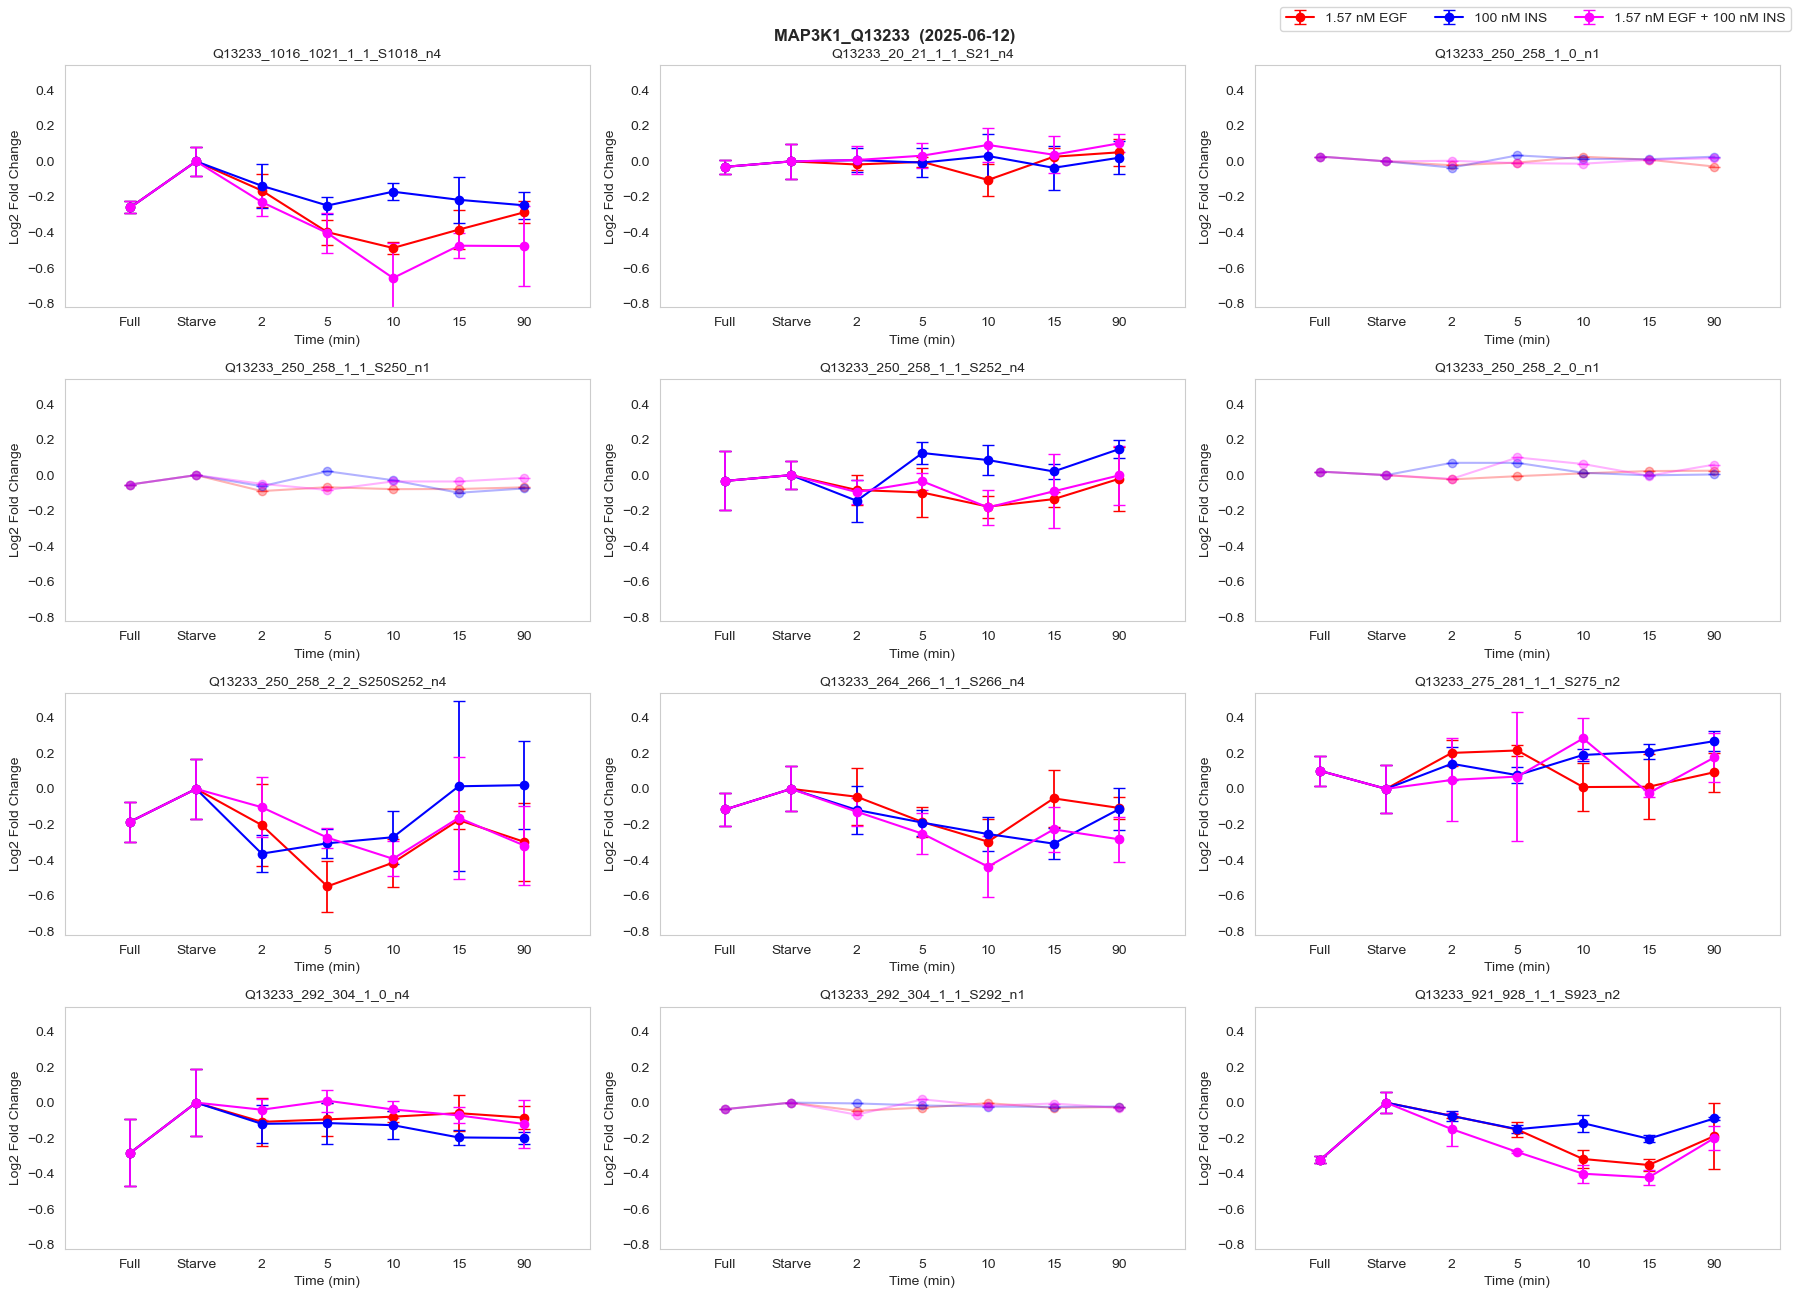

In [10]:
plot_protein_phosphosites(df_2_HME1, data_type = "log2FC", experiment = "2_hTERT_HME1",
                          proteins = ["MAP3K1"], replicates = False,  exclude_rep = [],
                          legend_plot = ['1.58 nM EGF', '100 nM INS', '1.58 nM EGF + 10 nM INS'], color_palette = ['r', 'b', 'fuchsia'],
                          saving_path = "",
                          saving_info = "", title_info = "",
                          plot_individually = False, fit_y_lims = False,
                          plot_close = False,
                          save_pdf = False, save_png = False)

In [12]:
df_2_HME1.loc[df_2_HME1['protein_name'] =='GAB1']

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,CV_raw_INS15,CV_raw_INS90,CV_raw_EGFnINS_full,CV_raw_EGFnINS_starve,CV_raw_EGFnINS2,CV_raw_EGFnINS5,CV_raw_EGFnINS10,CV_raw_EGFnINS15,CV_raw_EGFnINS90,CV_raw_All
17663,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,APSASVDSSLyNLPR,1.0000,251,259,1,1,Y259,...,75.415399,23.294187,14.617016,91.428548,43.996491,35.314026,9.710136,27.182012,1.305158,45.833049
17664,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,SYSHDVLPK,0.9940,264,266,1,0,0,...,15.515342,11.646669,5.355338,14.160647,17.383908,6.407121,10.011339,15.600368,12.940436,28.098911
17665,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,VSPSSTEADGELYVFNTPSGTSSVETQMR,1.0000,274,298,1,0,0,...,3.687224,9.901247,14.232898,6.782800,7.311614,8.236107,4.703272,10.679889,3.035151,12.358068
17666,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,VsPSSTEADGELYVFNTPSGTSSVETQMR,1.0000,274,298,1,1,S274,...,16.122498,15.349633,8.758365,8.578208,2.824514,3.278397,5.205804,41.377520,5.800261,14.464841
17667,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,VSPsSTEADGELYVFNTPSGTSSVETQMR,1.0000,274,298,1,1,S276,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.428721
17668,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,SSSLEGFHNHFK,0.9998,417,419,1,0,0,...,0.288826,16.431167,17.023939,19.668931,7.308697,0.469856,23.475603,5.557251,20.096477,38.976342
17669,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,SSsLEGFHNHFK,0.9999,417,419,1,1,S419,...,16.421153,14.561561,16.596361,40.737679,17.431213,6.547048,8.951412,38.805387,13.271029,43.529198
17670,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,NVLTVGSVSSEELDENYVPMNPNsPPR,1.0000,434,454,1,1,S454,...,16.899327,12.859567,18.060003,9.946066,19.967113,8.936990,12.567691,11.785093,15.811653,17.344254
17671,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,NVLTVGSVSSEELDENYVPMNPNSPPR,1.0000,434,454,2,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.806597
17672,Q13480,GRB2-associated-binding protein 1 OS=Homo sapi...,GAB1,QVEYLDLDLDSGK,1.0000,627,634,1,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.568741


In [28]:
df.loc[df["n_rep"]==1]


,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,CV_raw_INS15,CV_raw_INS90,CV_raw_EGFnINS_full,CV_raw_EGFnINS_starve,CV_raw_EGFnINS2,CV_raw_EGFnINS5,CV_raw_EGFnINS10,CV_raw_EGFnINS15,CV_raw_EGFnINS90,CV_raw_All
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.346090
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.437045
5,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSsSSSSYGSGR,1.0000,305,316,1,1,S309,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.899362
6,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSsSYGSGR,1.0000,305,316,1,1,S312,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.969743
7,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSsYGSGR,1.0000,305,316,1,1,S313,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.271801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.475756
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.985616
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.585989
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.384036
